In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('telco-customer-churn analysis.csv')

In [5]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
1. **customerID** → Unique identifier for each customer (not useful for analysis).
2. **gender** → Male/Female.
3. **SeniorCitizen** → 0 = Not Senior, 1 = Senior Citizen.
4. **Partner** → Whether the customer has a partner (Yes/No).
5. **Dependents** → Whether the customer has dependents (Yes/No).  # anybody is depending or not on the customer
6. **tenure** → Number of months the customer has stayed with the company.
7. **PhoneService** → Whether the customer has phone service (Yes/No).
8. **MultipleLines** → Multiple lines (Yes/No/No phone service).
9. **InternetService** → Type of internet (DSL, Fiber optic, No).
10. **OnlineSecurity** → Security add-on (Yes/No/No internet).
11. **OnlineBackup** → Backup add-on (Yes/No/No internet).
12. **DeviceProtection** → Device protection add-on (Yes/No/No internet).
13. **TechSupport** → Tech support add-on (Yes/No/No internet).
14. **StreamingTV** → Streaming TV (Yes/No/No internet).
15. **StreamingMovies** → Streaming Movies (Yes/No/No internet).
16. **Contract** → Type of contract (Month-to-month, One year, Two year).
17. **PaperlessBilling** → Paperless billing option (Yes/No).
18. **PaymentMethod** → Payment type (Electronic check, Mailed check, Bank transfer, Credit card).
19. **MonthlyCharges** → The amount charged per month (numeric).
20. **TotalCharges** → The total charges (stored as text → needs conversion to numeric).
21. **Churn** → Target variable (Yes = customer left, No = stayed).

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [16]:
df['TotalCharges'].unique()[30:60]

array(['6766.95', '181.65', '1874.45', '20.2', '45.25', '7251.7', '316.9',
       '3548.3', '3549.25', '1105.4', '475.7', '4872.35', '418.25',
       '4861.45', '981.45', '3906.7', '97', '144.15', '4217.8', '4254.1',
       '3838.75', '1426.4', '1752.65', '633.3', '4456.35', '1752.55',
       '6311.2', '7076.35', '894.3', '7853.7'], dtype=object)

In [20]:
pd.to_numeric(df['TotalCharges'], errors='coerce')

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [21]:
df['TotalCharges'].isnull().sum()

11

In [18]:
# Convert to numeric, forcing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [19]:
df['TotalCharges'].dtype

dtype('float64')

In [22]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [24]:
df.duplicated().sum()

0

In [25]:
# now will convert 0 and 1 to 'yes' and 'no' in 'SeniorCitizen' column
df['SeniorCitizen'] = df['SeniorCitizen'].replace({0:'no',1:'yes'})

In [27]:
# univariate analysis
1 will see the no of people left and present in the company

<Axes: xlabel='Churn', ylabel='count'>

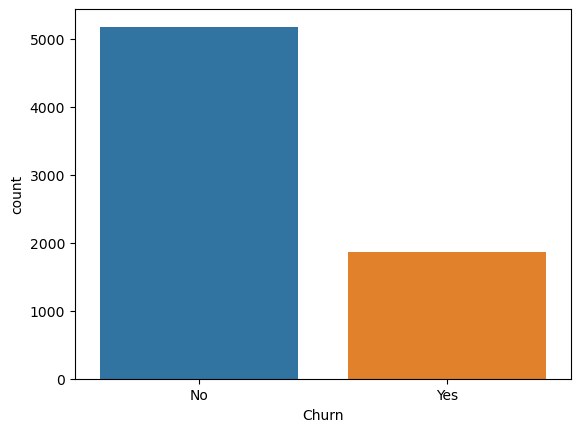

In [28]:
sns.countplot(x='Churn',data = df)

[Text(0, 0, '5174'), Text(0, 0, '1869')]

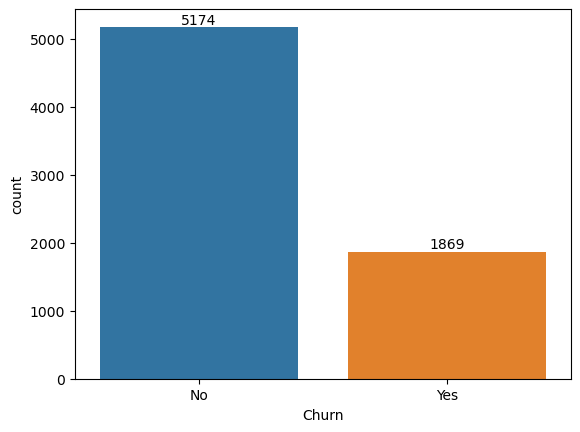

In [39]:
sd = sns.countplot(x='Churn',data = df)
sd.bar_label(sd.containers[0])

In [30]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Text(0.5, 1.0, 'churned customer')

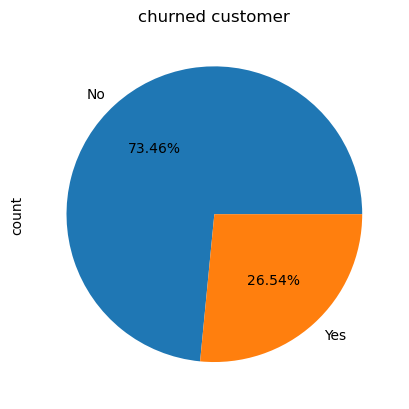

In [40]:
df['Churn'].value_counts().plot(kind='pie',autopct='%1.2f%%')
plt.title('churned customer')

In [ ]:
# try to explore from pie chart

<Axes: xlabel='gender', ylabel='count'>

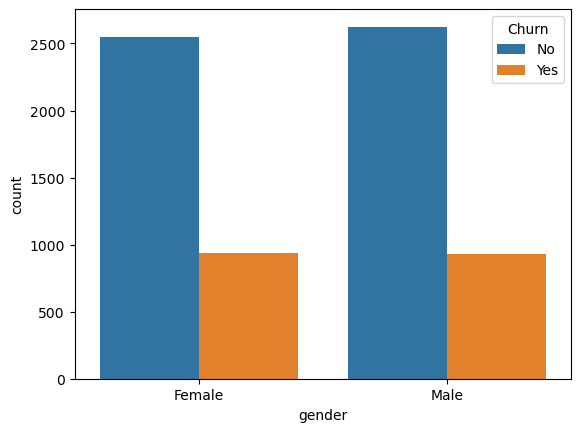

In [41]:
sns.countplot(x='gender',hue='Churn',data = df)

In [52]:
pd.crosstab(df['gender'],df['Churn'])

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


Since both genders have almost identical churn rates, gender-based retention strategies won’t be effective.

<Axes: xlabel='SeniorCitizen', ylabel='count'>

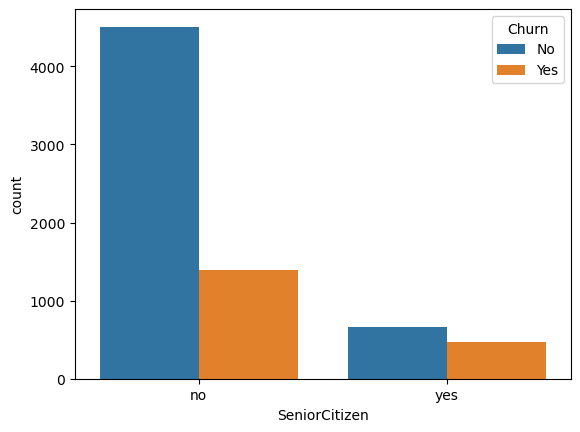

In [54]:
# lets try senior citizen
sns.countplot(x='SeniorCitizen',hue='Churn',data = df)

In [55]:
pd.crosstab(df['SeniorCitizen'],df['Churn'])

Churn,No,Yes
SeniorCitizen,,
no,4508,1393
yes,666,476


In [56]:
pd.crosstab(df['SeniorCitizen'],df['Churn'],normalize = 'index') * 100

Churn,No,Yes
SeniorCitizen,,
no,76.393832,23.606168
yes,58.318739,41.681261


Big difference in churn rates:

Non-senior citizens churn = 23.6%

Senior citizens churn = 41.7%
→ Senior citizens are much more likely to churn.

Risk factor:

Being a senior citizen almost doubles the chance of churn compared to non-seniors.

This suggests age group is an important predictor.

Business interpretation:

Senior customers may need better service, discounts, or support plans to stay.

They are a high-risk group worth targeting in churn reduction strategies.

<Axes: xlabel='Partner', ylabel='count'>

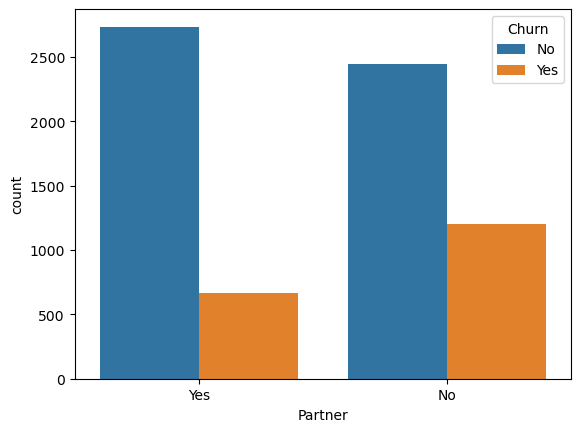

In [59]:
#lets try with partner
sns.countplot(x='Partner',hue='Churn',data = df)

In [60]:
pd.crosstab(df['Partner'],df['Churn'])

Churn,No,Yes
Partner,,
No,2441,1200
Yes,2733,669


In [61]:
pd.crosstab(df['Partner'],df['Churn'],normalize='index') * 100

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


In [ ]:
Without a Partner

67% did not churn, but 33% churned.

That’s a relatively high churn rate.

🔹 With a Partner

80% did not churn, only 20% churned.

Clearly, customers with a partner are more likely to stay.

<Axes: xlabel='Dependents', ylabel='count'>

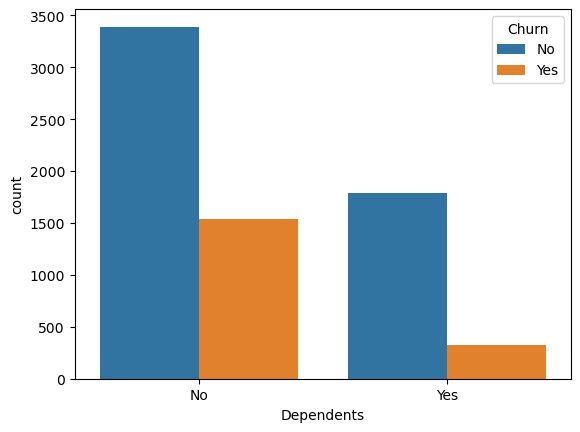

In [63]:
# lets try with dependents
sns.countplot(x='Dependents',hue='Churn',data = df)

In [65]:
pd.crosstab(df['Dependents'],df['Churn'],normalize='index') * 100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


In [ ]:
🔹 No Dependents

68.7% did not churn, but 31.3% churned.

That’s a much higher churn rate.

🔹 With Dependents

84.5% did not churn, only 15.5% churned.

Customers with dependents are far more loyal.

✅ Key Insight:
Having dependents (children/family responsibilities) makes customers less likely to churn.
Probably because they rely more on stable telecom services for family needs, education, or work.

<Axes: xlabel='tenure', ylabel='Count'>

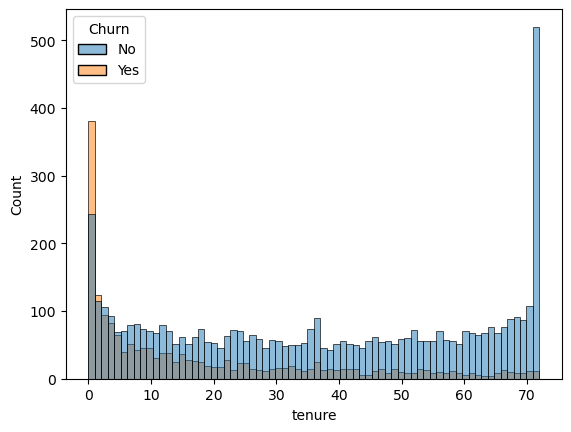

In [82]:
# lets try for tenure (numerical - categorical)
sns.histplot(x='tenure',hue='Churn',data = df,bins=70)

In [75]:
pd.crosstab(df['tenure'],df['Churn'],normalize='index') * 100

Churn,No,Yes
tenure,,
0,100.000000,0.000000
1,38.009788,61.990212
2,48.319328,51.680672
3,53.000000,47.000000
4,52.840909,47.159091
...,...,...
68,91.000000,9.000000
69,91.578947,8.421053
70,90.756303,9.243697


📊 Insights from Tenure (Telco Churn Dataset)

Most customers have low tenure (short-term customers).

The distribution is heavily right-skewed.

This means many customers leave within the first few months.

Churn is higher among new customers.

Customers with tenure 0–12 months are more likely to churn.

Suggests difficulty in retaining new customers.

Long-term customers are more loyal.

Customers with tenure above 3 years (36+ months) have a much lower churn rate.

Indicates that once customers stay longer, they build loyalty.

Business implication

The company should focus on onboarding and early retention strategies (e.g., better offers, customer support in the first year).

👉 In short: Tenure strongly affects churn — new customers leave quickly, long-term ones stay.

<Axes: xlabel='PhoneService', ylabel='count'>

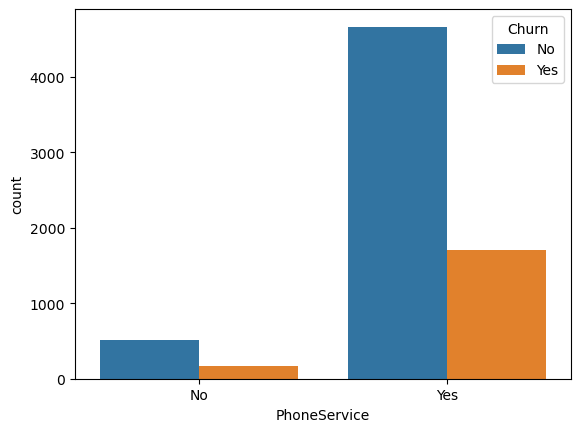

In [86]:
sns.countplot(x='PhoneService',hue='Churn',data = df)

In [87]:
pd.crosstab(df['PhoneService'],df['Churn'],normalize='index') * 100

Churn,No,Yes
PhoneService,,
No,75.073314,24.926686
Yes,73.290363,26.709637


In [ ]:
Phone Service & Churn Insights

Churn rate is similar for both groups

Customers with PhoneService → 26.7% churn

Customers without PhoneService → 24.9% churn

The difference is very small.

PhoneService alone is not a strong predictor of churn.

Having or not having a landline connection doesn’t influence churn much.

Possible explanation:

Today, mobile service is a basic utility, so nearly all customers have it.

Customers’ churn decisions are more influenced by internet service,
contract type, or billing charges than phone service.

In [ ]:
# 

In [88]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,7033,7034,7035,7036,7037,7038,7039,7040,7041,7042
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU,9305-CDSKC,1452-KIOVK,6713-OKOMC,7892-POOKP,6388-TABGU,...,9767-FFLEM,0639-TSIQW,8456-QDAVC,7750-EYXWZ,2569-WGERO,6840-RESVB,2234-XADUH,4801-JZAZL,8361-LTMKD,3186-AJIEK
gender,Female,Male,Male,Male,Female,Female,Male,Female,Female,Male,...,Male,Female,Male,Female,Female,Male,Female,Female,Male,Male
SeniorCitizen,no,no,no,no,no,no,no,no,no,no,...,no,no,no,no,no,no,no,no,yes,no
Partner,Yes,No,No,No,No,No,No,No,Yes,No,...,No,No,No,No,No,Yes,Yes,Yes,Yes,No
Dependents,No,No,No,No,No,No,Yes,No,No,Yes,...,No,No,No,No,No,Yes,Yes,Yes,No,No
tenure,1,34,2,45,2,8,22,10,28,62,...,38,67,19,12,72,24,72,11,4,66
PhoneService,No,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Yes,...,Yes,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Yes
MultipleLines,No phone service,No,No,No phone service,No,Yes,Yes,No phone service,Yes,No,...,No,Yes,No,No phone service,No,Yes,Yes,No phone service,Yes,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic,Fiber optic,Fiber optic,DSL,Fiber optic,DSL,...,Fiber optic,Fiber optic,Fiber optic,DSL,No,DSL,Fiber optic,DSL,Fiber optic,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No,No,No,Yes,No,Yes,...,No,Yes,No,No,No internet service,Yes,No,Yes,No,Yes


<Axes: xlabel='Contract', ylabel='count'>

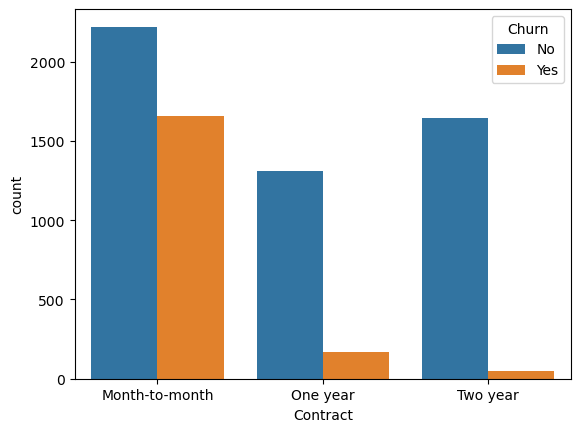

In [89]:
# lets try for contracts
sns.countplot(x='Contract',data = df,hue = 'Churn')

<Axes: ylabel='count'>

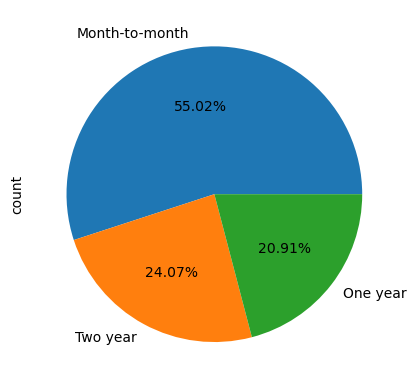

In [94]:
df['Contract'].value_counts().plot(kind='pie',autopct='%1.2f%%')

In [96]:
pd.crosstab(df['Contract'],df['Churn'],normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


📊 Insights:

Month-to-month contracts have the highest churn (42.7%) → Customers on flexible monthly plans are much more likely to leave.

One-year contracts drastically reduce churn (only 11.3%).

Two-year contracts are the most stable, with almost no churn (just 2.8%).

✅ Business takeaway:
Longer-term contracts improve customer retention. The telecom company could:

Encourage month-to-month users to switch to yearly plans (discounts, incentives).

Offer loyalty rewards for long-term subscribers.

👉 This shows how contract type is one of the strongest predictors of churn.

In [99]:
col = ['PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies']

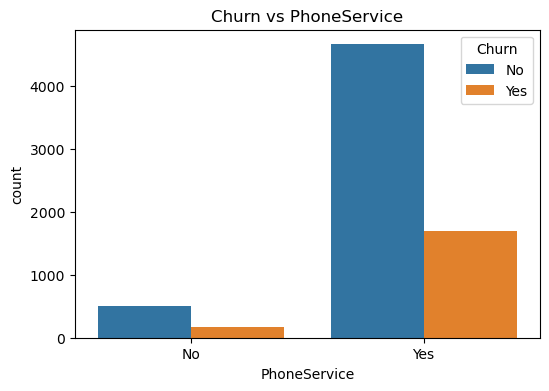

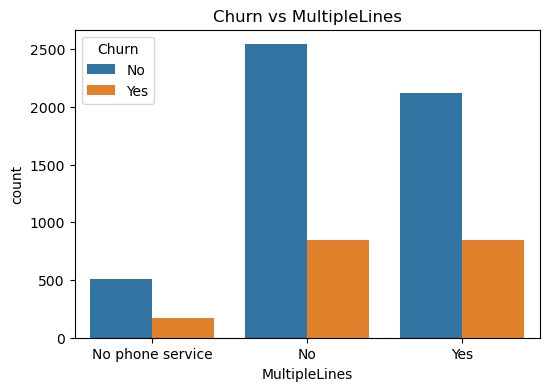

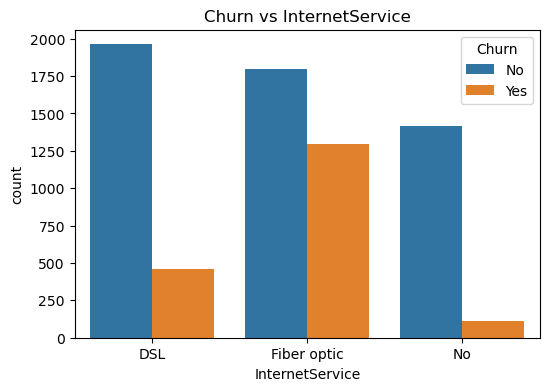

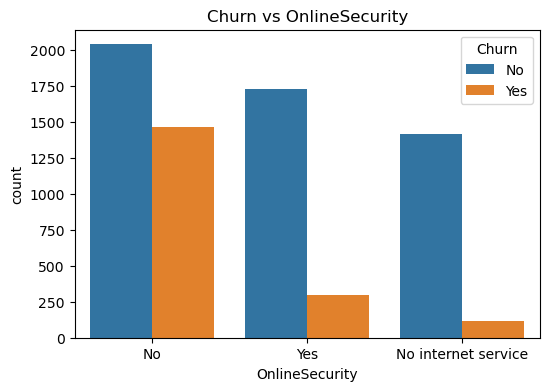

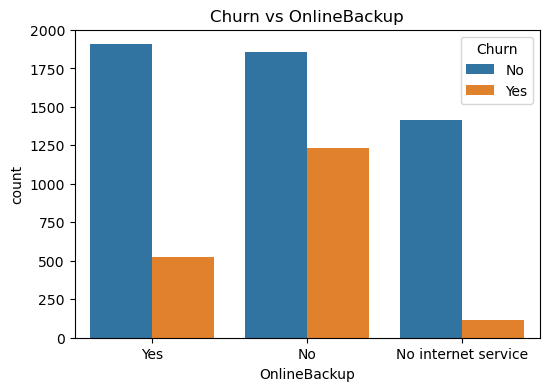

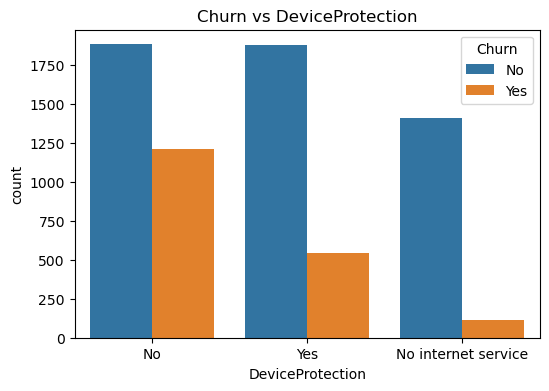

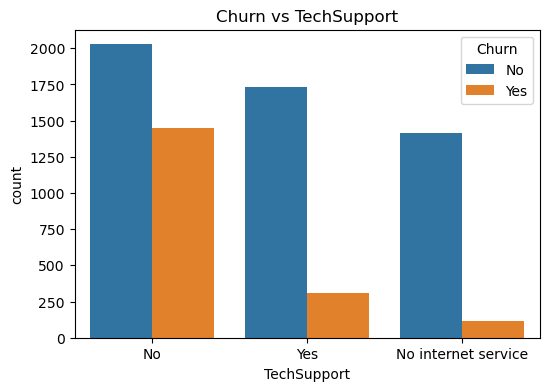

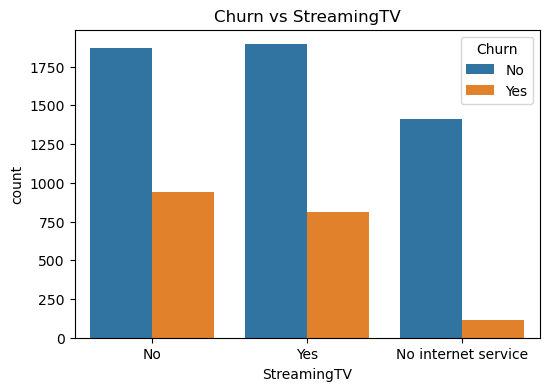

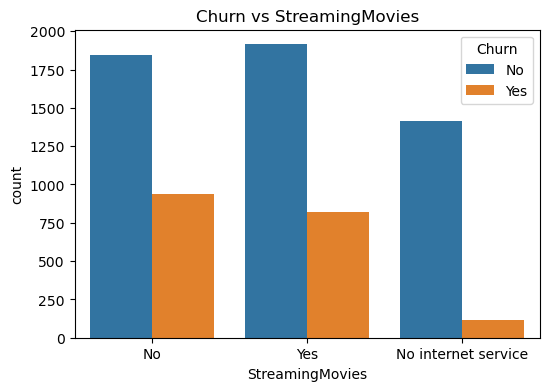

In [102]:
for i in col:
    plt.figure(figsize=(6,4))
    sns.countplot(x=i, data=df, hue='Churn')
    plt.title(f"Churn vs {i}")
    plt.show()

In [103]:
for i in col:
    print(pd.crosstab(df[i],df['Churn'],normalize='index') * 100)

Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637
Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194
Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494
Churn                       No        Yes
DeviceProtect

In [ ]:
### 📊 Insights

1. **PhoneService**

   * Customers with or without phone service have **similar churn** (\~25%).
   * 🔹 Phone service **does not strongly influence churn**.

---

2. **MultipleLines**

   * No lines: 25% churn
   * Multiple lines: 28.6% churn
   * No phone service: \~25% churn
   * 🔹 Having multiple lines increases churn slightly.

---

3. **InternetService**

   * DSL: **low churn** (19%).
   * Fiber optic: **very high churn** (42%).
   * No internet: **very low churn** (7%).
   * 🔹 Fiber optic customers are at **highest risk** of leaving.

---

4. **OnlineSecurity**

   * No: 41.7% churn (very high).
   * Yes: 14.6% churn (much lower).
   * No internet: 7.4% churn.
   * 🔹 **Online security is a strong retention factor.**

---

5. **OnlineBackup**

   * No: 39.9% churn.
   * Yes: 21.5% churn.
   * No internet: 7.4% churn.
   * 🔹 Having backup services reduces churn significantly.

---

6. **DeviceProtection**

   * No: 39.1% churn.
   * Yes: 22.5% churn.
   * No internet: 7.4% churn.
   * 🔹 Device protection also reduces churn.

---

7. **TechSupport**

   * No: 41.6% churn.
   * Yes: 15.1% churn.
   * No internet: 7.4% churn.
   * 🔹 Lack of tech support is a **major churn driver**.

---

8. **StreamingTV**

   * No: 33.5% churn.
   * Yes: 30.1% churn.
   * No internet: 7.4% churn.
   * 🔹 Streaming TV has **some churn effect**, but weaker compared to security/backup.

---

9. **StreamingMovies**

   * No: 33.7% churn.
   * Yes: 29.9% churn.
   * No internet: 7.4% churn.
   * 🔹 Streaming movies also shows **slightly higher churn**, but not as critical.

---

✅ **Overall takeaway:**

* **High-risk churn factors**: Fiber optic internet, No OnlineSecurity, No TechSupport.
* **Protective factors**: DSL internet, having security/backup/protection, long contracts.
* Entertainment services (StreamingTV/Movies) have **smaller impact**.


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

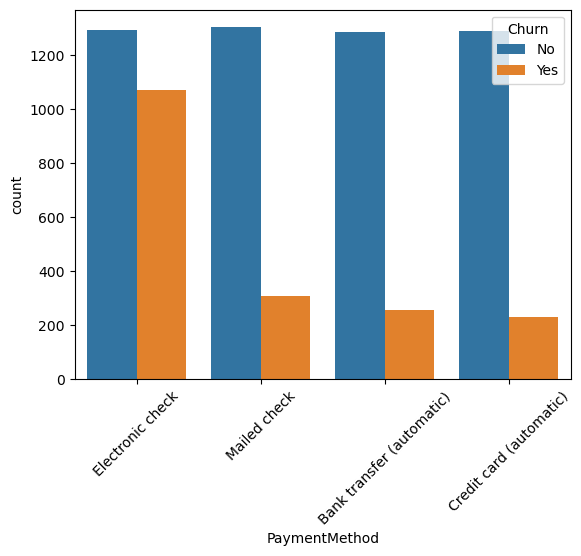

In [111]:
sns.countplot(x='PaymentMethod',data = df,hue = 'Churn')
plt.xticks(rotation = 45)

In [109]:
pd.crosstab(df['PaymentMethod'],df['Churn'],normalize='index') * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [ ]:
📊 Insights: Payment Method & Churn

Electronic check

Churn rate: 45% (highest among all).

🔹 Customers paying via e-check are most likely to leave.

Mailed check

Churn rate: 19%.

🔹 Customers using mailed checks churn much less.

Bank transfer (automatic)

Churn rate: 16.7%.

🔹 Very low churn, shows stability in automatic payments.

Credit card (automatic)

Churn rate: 15.2% (lowest).

🔹 Most loyal customers are those who pay automatically with credit cards.

✅ Overall takeaway:

Customers paying electronically (manual e-checks) are most unstable.

Customers on automatic payments (credit card / bank transfer) have the lowest churn → automation indicates commitment & convenience.

<Axes: xlabel='Churn', ylabel='TotalCharges'>

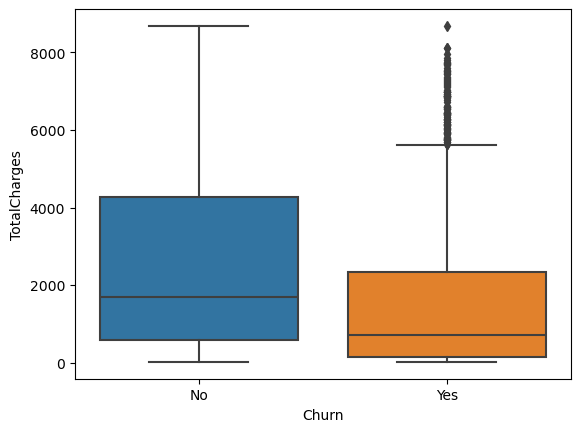

In [116]:
# try for total charges
sns.boxplot(y=df['TotalCharges'],x = 'Churn',data = df)

<Axes: xlabel='Churn', ylabel='TotalCharges'>

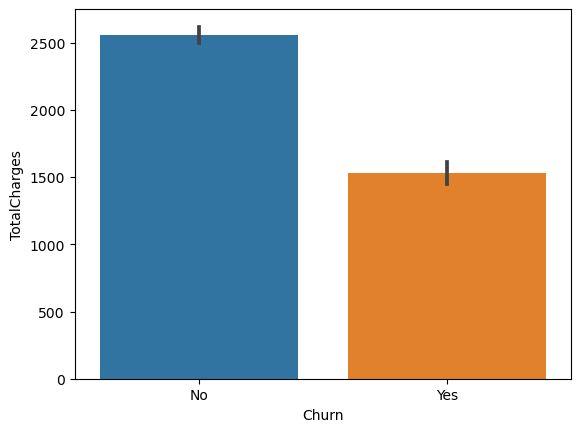

In [128]:
sns.barplot(x='Churn', y='TotalCharges', data=df)

<Axes: xlabel='TotalCharges', ylabel='Count'>

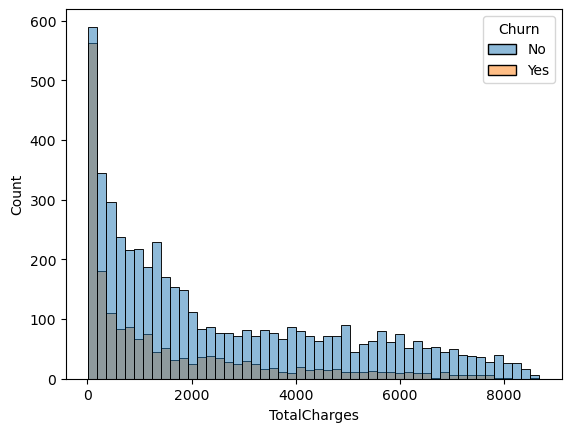

In [131]:
sns.histplot(hue='Churn', x='TotalCharges',bins=50, data=df)

In [ ]:
# 📌 Customer Churn Prediction Project

## 1. **Introduction**

Customer churn is when a customer stops using a company’s service. Reducing churn is crucial for telecom companies to maintain revenue and grow sustainably.
This project aims to analyze customer behavior, identify the key factors influencing churn, and build insights for business strategies.

---

## 2. **Problem Statement**

The telecom company is experiencing significant customer churn, especially among short-tenure and high-charge customers.
We need to identify:

* Which features strongly influence churn?
* How financial, service-related, and contract-related attributes affect churn.
* Business strategies to reduce churn rates.

---

## 3. **Dataset Description**

* **Source**: Telecom customer dataset
* **Rows**: \~7,000 customers
* **Features**:

  * **Demographics**: Gender, SeniorCitizen, Partner, Dependents
  * **Services**: PhoneService, InternetService, OnlineSecurity, TechSupport, StreamingTV, etc.
  * **Account Info**: Tenure, Contract, PaperlessBilling, PaymentMethod
  * **Financial**: MonthlyCharges, TotalCharges
  * **Target**: Churn (Yes/No)

---

## 4. **Exploratory Data Analysis (EDA) Insights**

### 🔹 Demographic Insights

* Gender → No significant effect.
* Senior Citizens churn more, but effect is moderate.

### 🔹 Service Insights

* Customers **without OnlineSecurity or TechSupport** have churn rates >40%.
* **Internet Service type** matters → Fiber optic users churn more compared to DSL.
* PhoneService showed minimal impact on churn.

### 🔹 Financial Insights

* **MonthlyCharges**: Higher monthly charges → higher churn probability.
* **TotalCharges**: Lower total charges (new customers) → higher churn.

### 🔹 Tenure Insights

* Churn is **highest in first 12 months**.
* Long-tenure customers (>2 years) are loyal.

### 🔹 Contract & Payment Insights

* **Contract Type**:

  * Month-to-month → highest churn.
  * One-year and two-year → significantly lower churn.
* **Payment Method**:

  * Electronic check users have highest churn.
* **Paperless Billing**: Higher churn compared to mailed billing.

---

## 5. **Conclusion**

* Churn is primarily driven by **short tenure, high monthly charges, lack of service add-ons, and flexible contracts**.
* **Key findings**:

  * Early-stage customers are at highest risk.
  * Bundled services (security/tech support) reduce churn.
  * Month-to-month contract customers are unstable.
  * Customers with higher charges are dissatisfied.

---

## 6. **Business Recommendations**

1. **Retention in early months**: Improve onboarding experience.
2. **Promote long-term contracts**: Discounts for 1- or 2-year plans.
3. **Service Bundles**: Offer OnlineSecurity/TechSupport at reduced prices.
4. **Target high-risk groups**: High monthly charges, electronic check users.
5. **Customer loyalty programs**: Rewards for customers staying beyond 1 year.

---

✅ **Final Note**: This project highlights that reducing churn requires focusing on **contract policies, customer experience in early months, and added service offerings**.